In [12]:
import numpy as np
import json
import gdsfactory as gf
import matplotlib.pyplot as plt
import sax

from utils import collect_leaf_params_for_proc_var

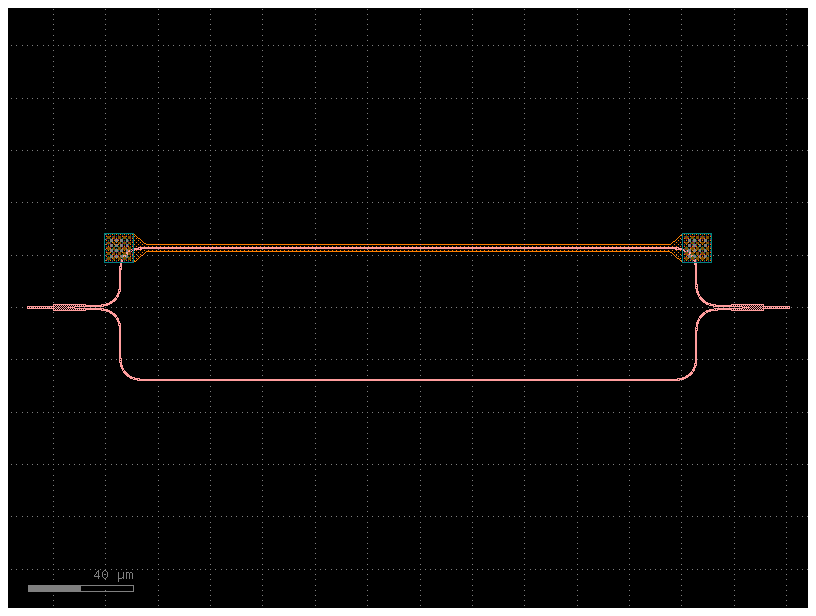

In [13]:
delta_length = 10
mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length
)
fig = mzi_component.plot()

In [14]:
def hps_equation_to_fit_dphase(temp, P_0, P_1):
    dphase = P_0 * temp + P_1
    div_by_pi, mod_by_pi = np.divmod(dphase, np.pi)
    return mod_by_pi - np.mod(div_by_pi, 2) * np.pi


# based off of lmtimesim/lmtimesim/components_proc_var/local_sim_comps/hps_phase_shifter.py
class HPS_PhaseShifter_Proc_Var:

    def __init__(
        self,
        model_params_for_proc_var: dict | None = None,
    ):
        assert (
            model_params_for_proc_var is not None
        ), "model_params_for_proc_var must be provided"
        dphase_lookup = collect_leaf_params_for_proc_var(
            model_params_for_proc_var, "dphasete"
        )
        self._dphasete_P0_lookup = collect_leaf_params_for_proc_var(
            dphase_lookup, "P_0"
        )
        self._dphasete_P1_lookup = collect_leaf_params_for_proc_var(
            dphase_lookup, "P_1"
        )
        self._trans_lookup = collect_leaf_params_for_proc_var(
            model_params_for_proc_var, "losste"
        )

        # construct data structures to hold the model parameters in numpy.array
        assert (
            self._dphasete_P0_lookup.keys()
            == self._dphasete_P1_lookup.keys()
            == self._trans_lookup.keys()
        )
        self._wl2index = {k: i for i, k in enumerate(self._dphasete_P0_lookup.keys())}
        self._dphasete_P0_lookup = np.array(list(self._dphasete_P0_lookup.values()))
        self._dphasete_P1_lookup = np.array(list(self._dphasete_P1_lookup.values()))
        self._trans_lookup = np.array(list(self._trans_lookup.values()))

        # Thermal properties
        self._heater_voltage = 0.0
        self.thermal_time_constant1 = 6.15e-6
        self.thermal_time_constant2 = 56e-6
        self.thermal_weight1 = 0.67
        self.thermal_weight2 = 0.33
        self.heater_coeff_A = -2.19042885e-5
        self.heater_coeff_B = -2.12241092e-5
        self.heater_coeff_C = 1.12634676e-3
        self.thermal_resistance = 5012  # Degrees C per Watt
        self._waveguide_temperature = 0
        self._temperature = 378.15  # ambient temperature in K

        # time domain properties
        self._rc_filter_bool = True
        self._time_state: float = 0.0

        # simulation properties
        self._wavelength = np.atleast_1d("1.30147e-06")
        self._wavelength_indexes = self._get_wl_indexes()

    def _get_wl_indexes(self):
        return np.array([self._wl2index[wl] for wl in self._wavelength])

    @property
    def rc_filter_bool(self):
        return self._rc_filter_bool

    @rc_filter_bool.setter
    def rc_filter_bool(self, new_rc_filter_bool):
        self._rc_filter_bool = new_rc_filter_bool

    @property
    def heater_power(self):
        heater_current = (
            self.heater_coeff_A * np.power(self._heater_voltage, 3)
            + self.heater_coeff_B * np.power(self._heater_voltage, 2)
            + self.heater_coeff_C * self._heater_voltage
        )
        return heater_current * self._heater_voltage

    @property
    def waveguide_temperature(self):
        new_temp = self.thermal_resistance * self.heater_power + self._temperature
        if self.rc_filter_bool is True:
            t0 = self._time_state
            t1 = self._time
            self._waveguide_temperature = self._waveguide_temperature + (
                new_temp - self._waveguide_temperature
            ) * (
                1
                - self.thermal_weight1
                * np.exp(-(t1 - t0) / self.thermal_time_constant1)
                - self.thermal_weight2
                * np.exp(-(t1 - t0) / self.thermal_time_constant2)
            )
        elif self.rc_filter_bool is False:
            self._waveguide_temperature = new_temp

        return self._waveguide_temperature

    @property
    def trans(self):
        return self._trans_lookup[self._get_wl_indexes()]

    @property
    def phase_change(self):
        return hps_equation_to_fit_dphase(
            self.waveguide_temperature,
            self._dphasete_P0_lookup[self._get_wl_indexes()],
            self._dphasete_P1_lookup[self._get_wl_indexes()],
        )

    def _construct_smatrix(self):
        s21 = np.sqrt(self.trans) * np.exp(-1j * self.phase_change)
        return [[0.0, s21], [s21, 0.0]]

    def __call__(self, wl=1.30147e-06, time=0.0, voltage=0.0):
        self._wavelength = np.atleast_1d(wl).astype(str)
        self._time = time
        self._heater_voltage = voltage

        s_mat = self._construct_smatrix()

        self._time_state = self._time
        print(f'time_state = {self._time_state}')
        return sax.reciprocal(
            {
                ("o1", "o2"): s_mat[0][1],
            }
        )


def straight(wl=1.5, length=10.0, neff=2.4):
    return sax.reciprocal({("o1", "o2"): np.exp(2j * np.pi * neff * length / wl)})


def mmi1x2():
    """Returns a perfect 1x2 splitter."""
    return sax.reciprocal(
        {
            ("o1", "o2"): 0.5**0.5,
            ("o1", "o3"): 0.5**0.5,
        }
    )


def bend_euler(wl=1.5, length=20.0):
    """Returns bend Sparameters with reduced transmission compared to a straight."""
    return {k: 0.99 * v for k, v in straight(wl=wl, length=length).items()}

time_state = 0.0
time_state = 0.0001


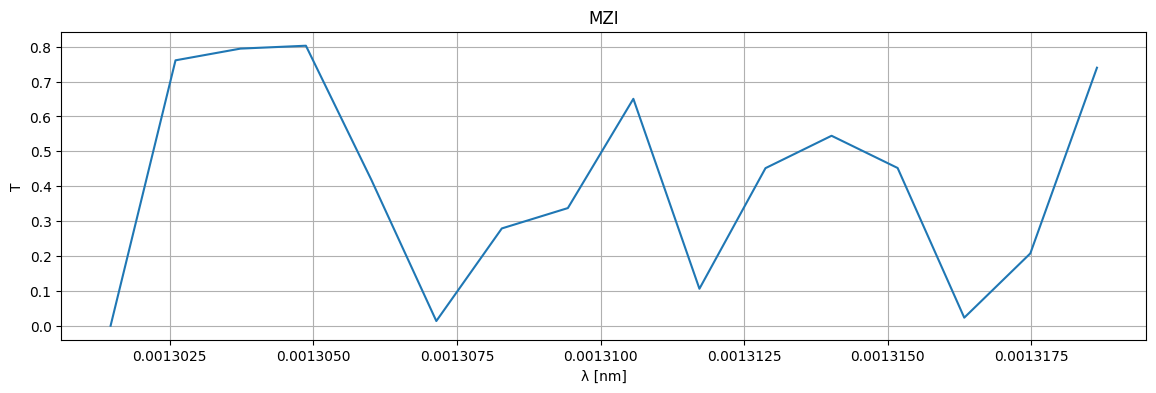

In [33]:
from pathlib import Path
mc_param_file_path = Path('/Users/gongyu/Work/stax/tests/lmts_hps/hps_model_params.json')

# load mc_params from file
with open(mc_param_file_path, "r") as f:
    hps_mc_params = json.load(f)

def create_hps_phase_shifter_proc_var() -> sax.Model:
    return HPS_PhaseShifter_Proc_Var(model_params_for_proc_var=hps_mc_params[0])

assert sax.is_model_factory(create_hps_phase_shifter_proc_var)

models = {
    "bend_euler": bend_euler,
    "mmi1x2": mmi1x2,
    "straight": straight,
    "straight_heater_metal_undercut": create_hps_phase_shifter_proc_var,
}

mzi_component = gf.components.mzi_phase_shifter_top_heater_metal(
    delta_length=delta_length,
)
netlist = mzi_component.get_netlist()
mzi_circuit, cir_info = sax.circuit(
    netlist=netlist,
    models=models,
    ignore_missing_ports=True,
)

wl = np.array(
    [
        1.30147e-06,
        1.3026e-06,
        1.30373e-06,
        1.30487e-06,
        1.30601e-06,
        1.30714e-06,
        1.30828e-06,
        1.30943e-06,
        1.31057e-06,
        1.31172e-06,
        1.31287e-06,
        1.31402e-06,
        1.31517e-06,
        1.31633e-06,
        1.31748e-06,
        1.31864e-06,
    ]
)
S = mzi_circuit(wl=wl, time=0.0001)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)  # type: ignore
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()


time_state = 0.0002


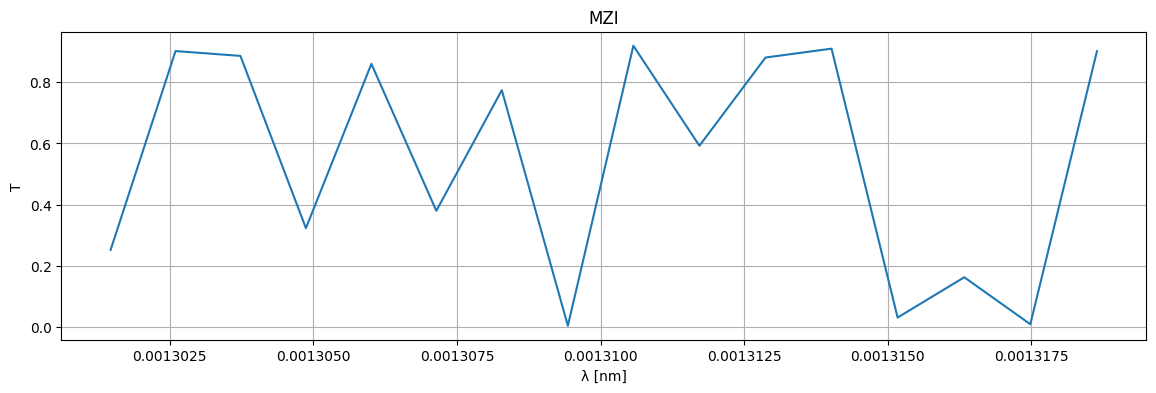

In [35]:
S = mzi_circuit(wl=wl, time=0.0002)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)  # type: ignore
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()

time_state = 0.0009


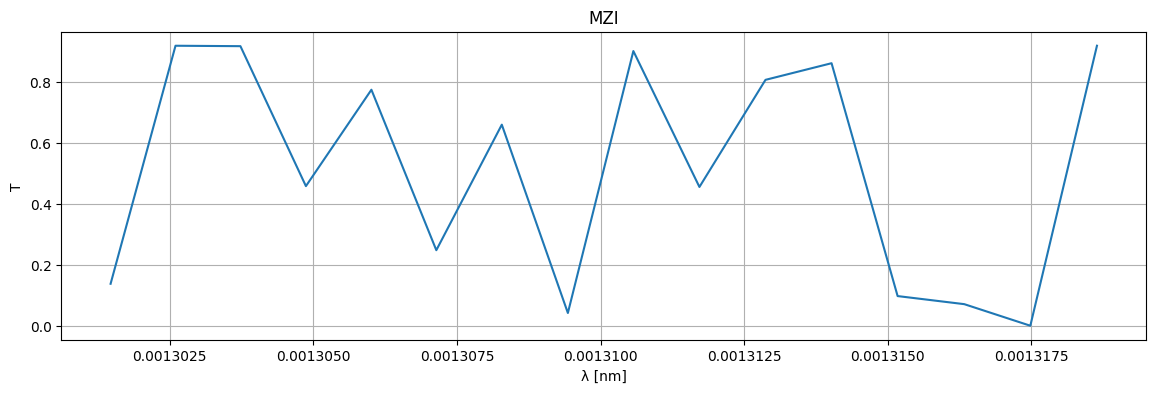

In [36]:
S = mzi_circuit(wl=wl, time=0.0009)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)  # type: ignore
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()

time_state = 0.001


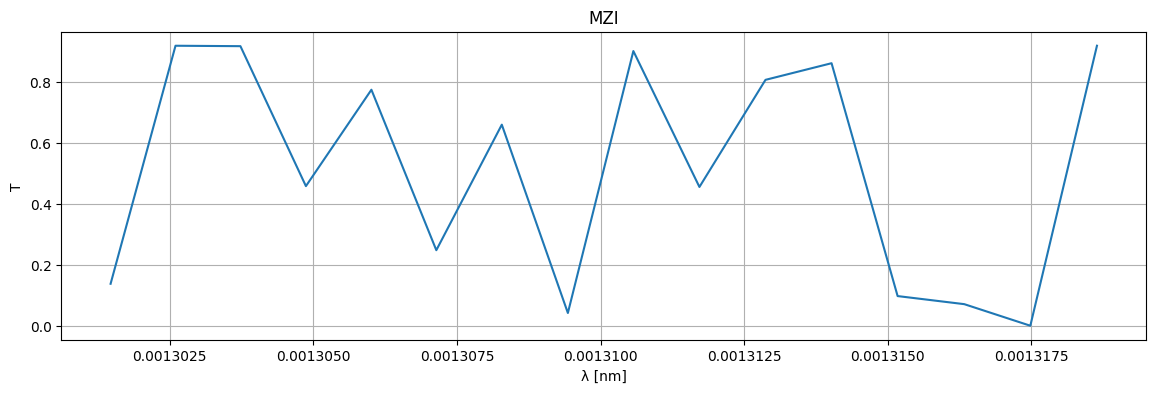

In [37]:
S = mzi_circuit(wl=wl, time=0.001)

plt.figure(figsize=(14, 4))
plt.title("MZI")
plt.plot(1e3 * wl, np.abs(S["o1", "o2"]) ** 2)  # type: ignore
plt.xlabel("λ [nm]")
plt.ylabel("T")
plt.grid(True)
plt.show()

The above shows that the `time` parameter plays a key role in determining the simulation results and as the time becomes longer than the thermal time constants of HPS, the simulation results stabilizes.

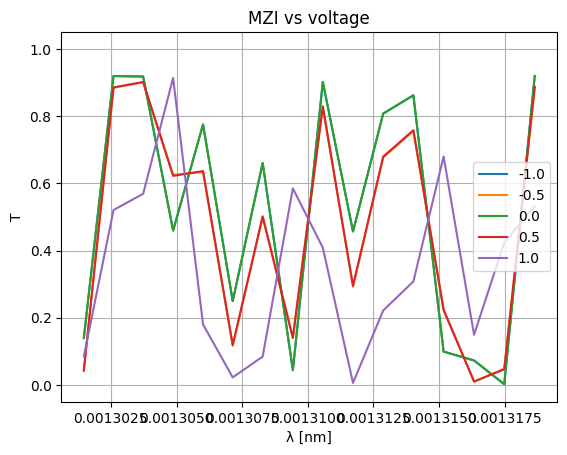

In [11]:

voltages = np.linspace(-1, 1, num=5)

for i, voltage in enumerate(voltages):
    S = mzi_circuit(
        wl=wl,
        time=0.1 * (i + 1),
        sxt={"voltage": voltage},
    )
    plt.plot(wl * 1e3, abs(S["o1", "o2"]) ** 2, label=str(voltage))  # type: ignore
    plt.xlabel("λ [nm]")
    plt.ylabel("T")
    plt.ylim(-0.05, 1.05)
    plt.grid(True)

plt.title("MZI vs voltage")
plt.legend()
plt.show()
